In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import shap
from azure.storage.blob import BlobServiceClient

load_dotenv()
plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")

df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

print(f"✅ Master dataset loaded: {df.shape}")
print(f"\nDistribusi Risiko Gagal Panen:")
print(df['risiko_gagal_panen'].value_counts())
print(f"\nClass balance: {df['risiko_gagal_panen'].mean():.1%} berisiko")

python-dotenv could not parse statement starting at line 1


✅ Master dataset loaded: (1624, 51)

Distribusi Risiko Gagal Panen:
risiko_gagal_panen
0    1218
1     406
Name: count, dtype: int64

Class balance: 25.0% berisiko


In [2]:
FEATURE_COLS = [
    'enso_mean', 'enso_lag1_mean', 'enso_lag3_mean', 'bulan_el_nino', 'bulan_la_nina',
    'curah_hujan_total', 'curah_hujan_mean', 'curah_hujan_std', 'curah_hujan_max',
    'hari_hujan_total', 'suhu_mean', 'suhu_max', 'kelembaban_mean',
    'anomali_curah_hujan', 'pct_anomali_hujan',
    'ndvi_mean', 'ndvi_max', 'ndvi_std', 'pct_lahan_sangat_baik', 'pct_lahan_buruk',
    'skor_irigasi', 'jumlah_pompa_unit', 'kapasitas_pompa_per_ha',
    'indeks_pertanaman', 'persen_irigasi_kondisi_baik', 'era_pompanisasi',
    'harga_mean', 'harga_lag1', 'harga_volatility', 'harga_yoy_change',
    'rasio_gabah_beras', 'impor_volume', 'harga_impor_idr',
    'luas_panen_ha', 'musim_tanam_enc', 'provinsi_enc'
]

TARGET = 'risiko_gagal_panen'

available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f"✅ Features: {len(available_features)}")

X = df[available_features].copy()
y = df[TARGET].copy()

# Stratified split — penting untuk imbalanced class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nClass distribution train:")
print(y_train.value_counts())
print(f"\nClass distribution test:")
print(y_test.value_counts())

✅ Features: 36
✅ Train: (1299, 36) | Test: (325, 36)

Class distribution train:
risiko_gagal_panen
0    974
1    325
Name: count, dtype: int64

Class distribution test:
risiko_gagal_panen
0    244
1     81
Name: count, dtype: int64


In [3]:
print("🤖 Training Classification Models...")
print("=" * 60)

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    f1        = f1_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall    = recall_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_prob) if y_prob is not None else 0
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1').mean()
    
    print(f"\n📊 {name}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   Precision : {precision:.4f}")
    print(f"   Recall    : {recall:.4f}")
    print(f"   ROC-AUC   : {auc:.4f}")
    print(f"   CV F1     : {cv_f1:.4f}")
    
    return {
        'model': name, 'f1': f1, 'precision': precision,
        'recall': recall, 'auc': auc, 'cv_f1': cv_f1,
        'y_pred': y_pred, 'y_prob': y_prob, 'fitted_model': model
    }

results = []

# 1. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
r = evaluate_classifier("Logistic Regression", lr,
                         X_train_scaled, y_train, X_test_scaled, y_test)
results.append(r)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
r = evaluate_classifier("Random Forest", rf, X_train, y_train, X_test, y_test)
results.append(r)

# 3. XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_pos, random_state=42,
    n_jobs=-1, verbosity=0
)
r = evaluate_classifier("XGBoost", xgb_clf, X_train, y_train, X_test, y_test)
results.append(r)

# 4. LightGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    class_weight='balanced', random_state=42,
    n_jobs=-1, verbose=-1
)
r = evaluate_classifier("LightGBM", lgb_clf, X_train, y_train, X_test, y_test)
results.append(r)

print("\n" + "=" * 60)
print("🏆 RANGKUMAN SEMUA MODEL KLASIFIKASI")
print("=" * 60)
df_results = pd.DataFrame([{k: v for k, v in r.items() 
                             if k not in ['y_pred','y_prob','fitted_model']} 
                            for r in results])
print(df_results.to_string(index=False))

🤖 Training Classification Models...

📊 Logistic Regression
   F1-Score  : 0.8172
   Precision : 0.7238
   Recall    : 0.9383
   ROC-AUC   : 0.9712
   CV F1     : 0.8099

📊 Random Forest
   F1-Score  : 0.8521
   Precision : 0.8182
   Recall    : 0.8889
   ROC-AUC   : 0.9680
   CV F1     : 0.7906

📊 XGBoost
   F1-Score  : 0.8136
   Precision : 0.7500
   Recall    : 0.8889
   ROC-AUC   : 0.9651
   CV F1     : 0.7945

📊 LightGBM
   F1-Score  : 0.8391
   Precision : 0.7849
   Recall    : 0.9012
   ROC-AUC   : 0.9655
   CV F1     : 0.7981

🏆 RANGKUMAN SEMUA MODEL KLASIFIKASI
              model       f1  precision   recall      auc    cv_f1
Logistic Regression 0.817204   0.723810 0.938272 0.971210 0.809882
      Random Forest 0.852071   0.818182 0.888889 0.967997 0.790599
            XGBoost 0.813559   0.750000 0.888889 0.965088 0.794499
           LightGBM 0.839080   0.784946 0.901235 0.965493 0.798126


In [4]:
from sklearn.model_selection import RandomizedSearchCV

print("🔧 Hyperparameter Tuning XGBoost Classifier...")

param_dist = {
    'n_estimators'    : [200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [4, 6, 8],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2],
    'reg_alpha'       : [0, 0.1, 0.5],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42, n_jobs=-1, verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=30, cv=cv, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best params: {random_search.best_params_}")
print(f"✅ Best CV F1 : {random_search.best_score_:.4f}")

best_clf = random_search.best_estimator_
y_pred_best = best_clf.predict(X_test)
y_prob_best = best_clf.predict_proba(X_test)[:, 1]

f1_best  = f1_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best  = recall_score(y_test, y_pred_best)
auc_best  = roc_auc_score(y_test, y_prob_best)

print(f"\n🏆 BEST XGBoost Classifier:")
print(f"   F1-Score  : {f1_best:.4f}")
print(f"   Precision : {prec_best:.4f}")
print(f"   Recall    : {rec_best:.4f}")
print(f"   ROC-AUC   : {auc_best:.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['Aman','Berisiko'])}")

🔧 Hyperparameter Tuning XGBoost Classifier...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'subsample': 0.7, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
✅ Best CV F1 : 0.8140

🏆 BEST XGBoost Classifier:
   F1-Score  : 0.8333
   Precision : 0.7576
   Recall    : 0.9259
   ROC-AUC   : 0.9665

              precision    recall  f1-score   support

        Aman       0.97      0.90      0.94       244
    Berisiko       0.76      0.93      0.83        81

    accuracy                           0.91       325
   macro avg       0.87      0.91      0.88       325
weighted avg       0.92      0.91      0.91       325



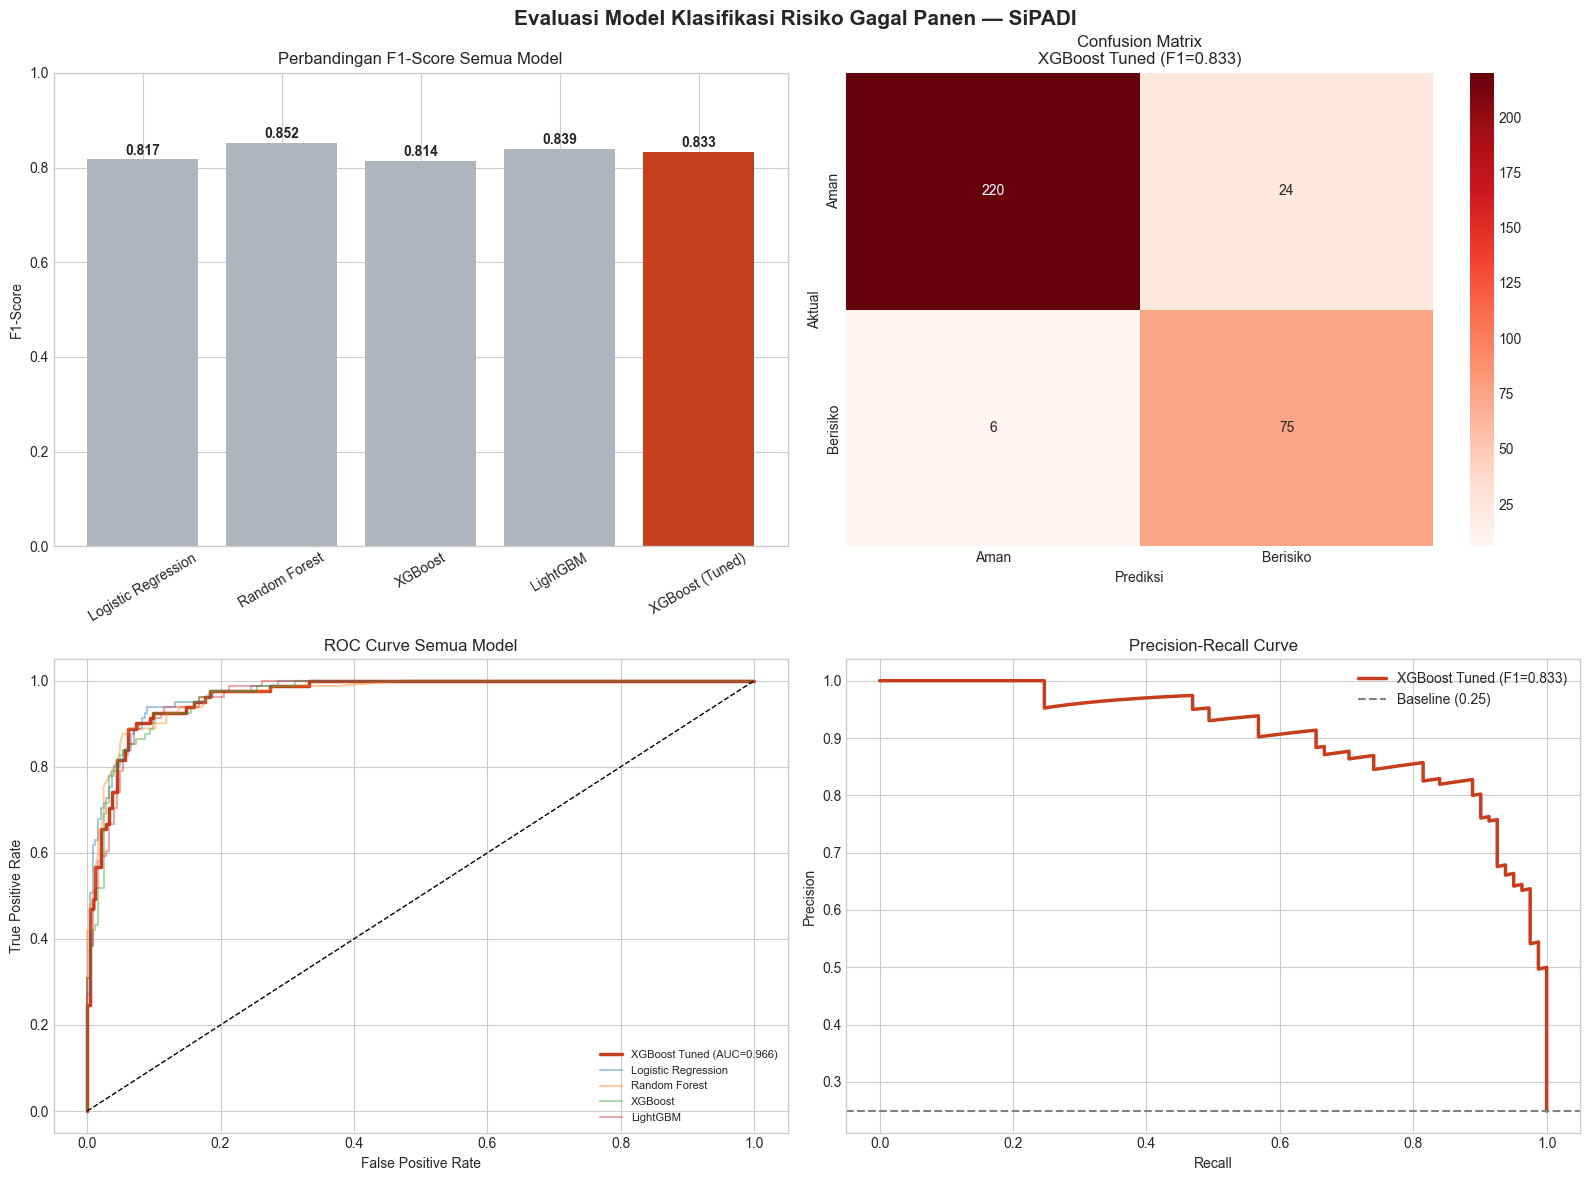

✅ Plot evaluasi tersimpan!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evaluasi Model Klasifikasi Risiko Gagal Panen — SiPADI',
             fontsize=15, fontweight='bold')

# Plot 1: Model comparison F1
ax = axes[0, 0]
model_names = [r['model'] for r in results] + ['XGBoost (Tuned)']
f1_values   = [r['f1'] for r in results] + [f1_best]
colors = ['#adb5bd'] * len(results) + ['#C73E1D']
bars = ax.bar(model_names, f1_values, color=colors)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score Semua Model')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Confusion Matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Aman', 'Berisiko'],
            yticklabels=['Aman', 'Berisiko'])
ax.set_ylabel('Aktual')
ax.set_xlabel('Prediksi')
ax.set_title(f'Confusion Matrix\nXGBoost Tuned (F1={f1_best:.3f})')

# Plot 3: ROC Curve
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
ax.plot(fpr, tpr, color='#C73E1D', linewidth=2.5,
        label=f'XGBoost Tuned (AUC={auc_best:.3f})')
for r in results:
    if r['y_prob'] is not None:
        fpr_r, tpr_r, _ = roc_curve(y_test, r['y_prob'])
        ax.plot(fpr_r, tpr_r, alpha=0.4, linewidth=1.5, label=r['model'])
ax.plot([0,1], [0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Semua Model')
ax.legend(fontsize=8)

# Plot 4: Precision-Recall Curve
ax = axes[1, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_best)
ax.plot(rec_curve, prec_curve, color='#C73E1D', linewidth=2.5,
        label=f'XGBoost Tuned (F1={f1_best:.3f})')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--',
           label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'model_classification_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot evaluasi tersimpan!")

In [6]:
print("💾 Menyimpan model klasifikasi...")

joblib.dump(best_clf, MODELS_DIR / 'risk_classifier.pkl')
print("✅ Model tersimpan lokal!")

blob_service = BlobServiceClient.from_connection_string(
    os.getenv("AZURE_STORAGE_CONNECTION_STRING")
)
blob_client = blob_service.get_blob_client(
    container="sipadi-models",
    blob="models/risk_classifier.pkl"
)
with open(MODELS_DIR / 'risk_classifier.pkl', "rb") as f:
    blob_client.upload_blob(f, overwrite=True)
print("☁️  Uploaded: models/risk_classifier.pkl")

print("\n" + "=" * 60)
print("🏆 FINAL MODEL SUMMARY — KLASIFIKASI")
print("=" * 60)
print(f"   Model     : XGBoost Classifier (Tuned)")
print(f"   Features  : {len(available_features)}")
print(f"   F1-Score  : {f1_best:.4f}")
print(f"   Precision : {prec_best:.4f}")
print(f"   Recall    : {rec_best:.4f}")
print(f"   ROC-AUC   : {auc_best:.4f}")
print(f"   Storage   : Azure Blob (sipadi-models)")
print("=" * 60)

💾 Menyimpan model klasifikasi...
✅ Model tersimpan lokal!
☁️  Uploaded: models/risk_classifier.pkl

🏆 FINAL MODEL SUMMARY — KLASIFIKASI
   Model     : XGBoost Classifier (Tuned)
   Features  : 36
   F1-Score  : 0.8333
   Precision : 0.7576
   Recall    : 0.9259
   ROC-AUC   : 0.9665
   Storage   : Azure Blob (sipadi-models)
